# 🏡 California House Price Prediction

End-to-end ML project using the California Housing dataset.  
Models: Linear Regression, Decision Tree, Random Forest + GridSearchCV.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit, cross_val_score, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

## 1. Data Loading & Exploration

In [2]:
df = pd.read_csv('housing.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [4]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [5]:
# Distribution of categorical feature
df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

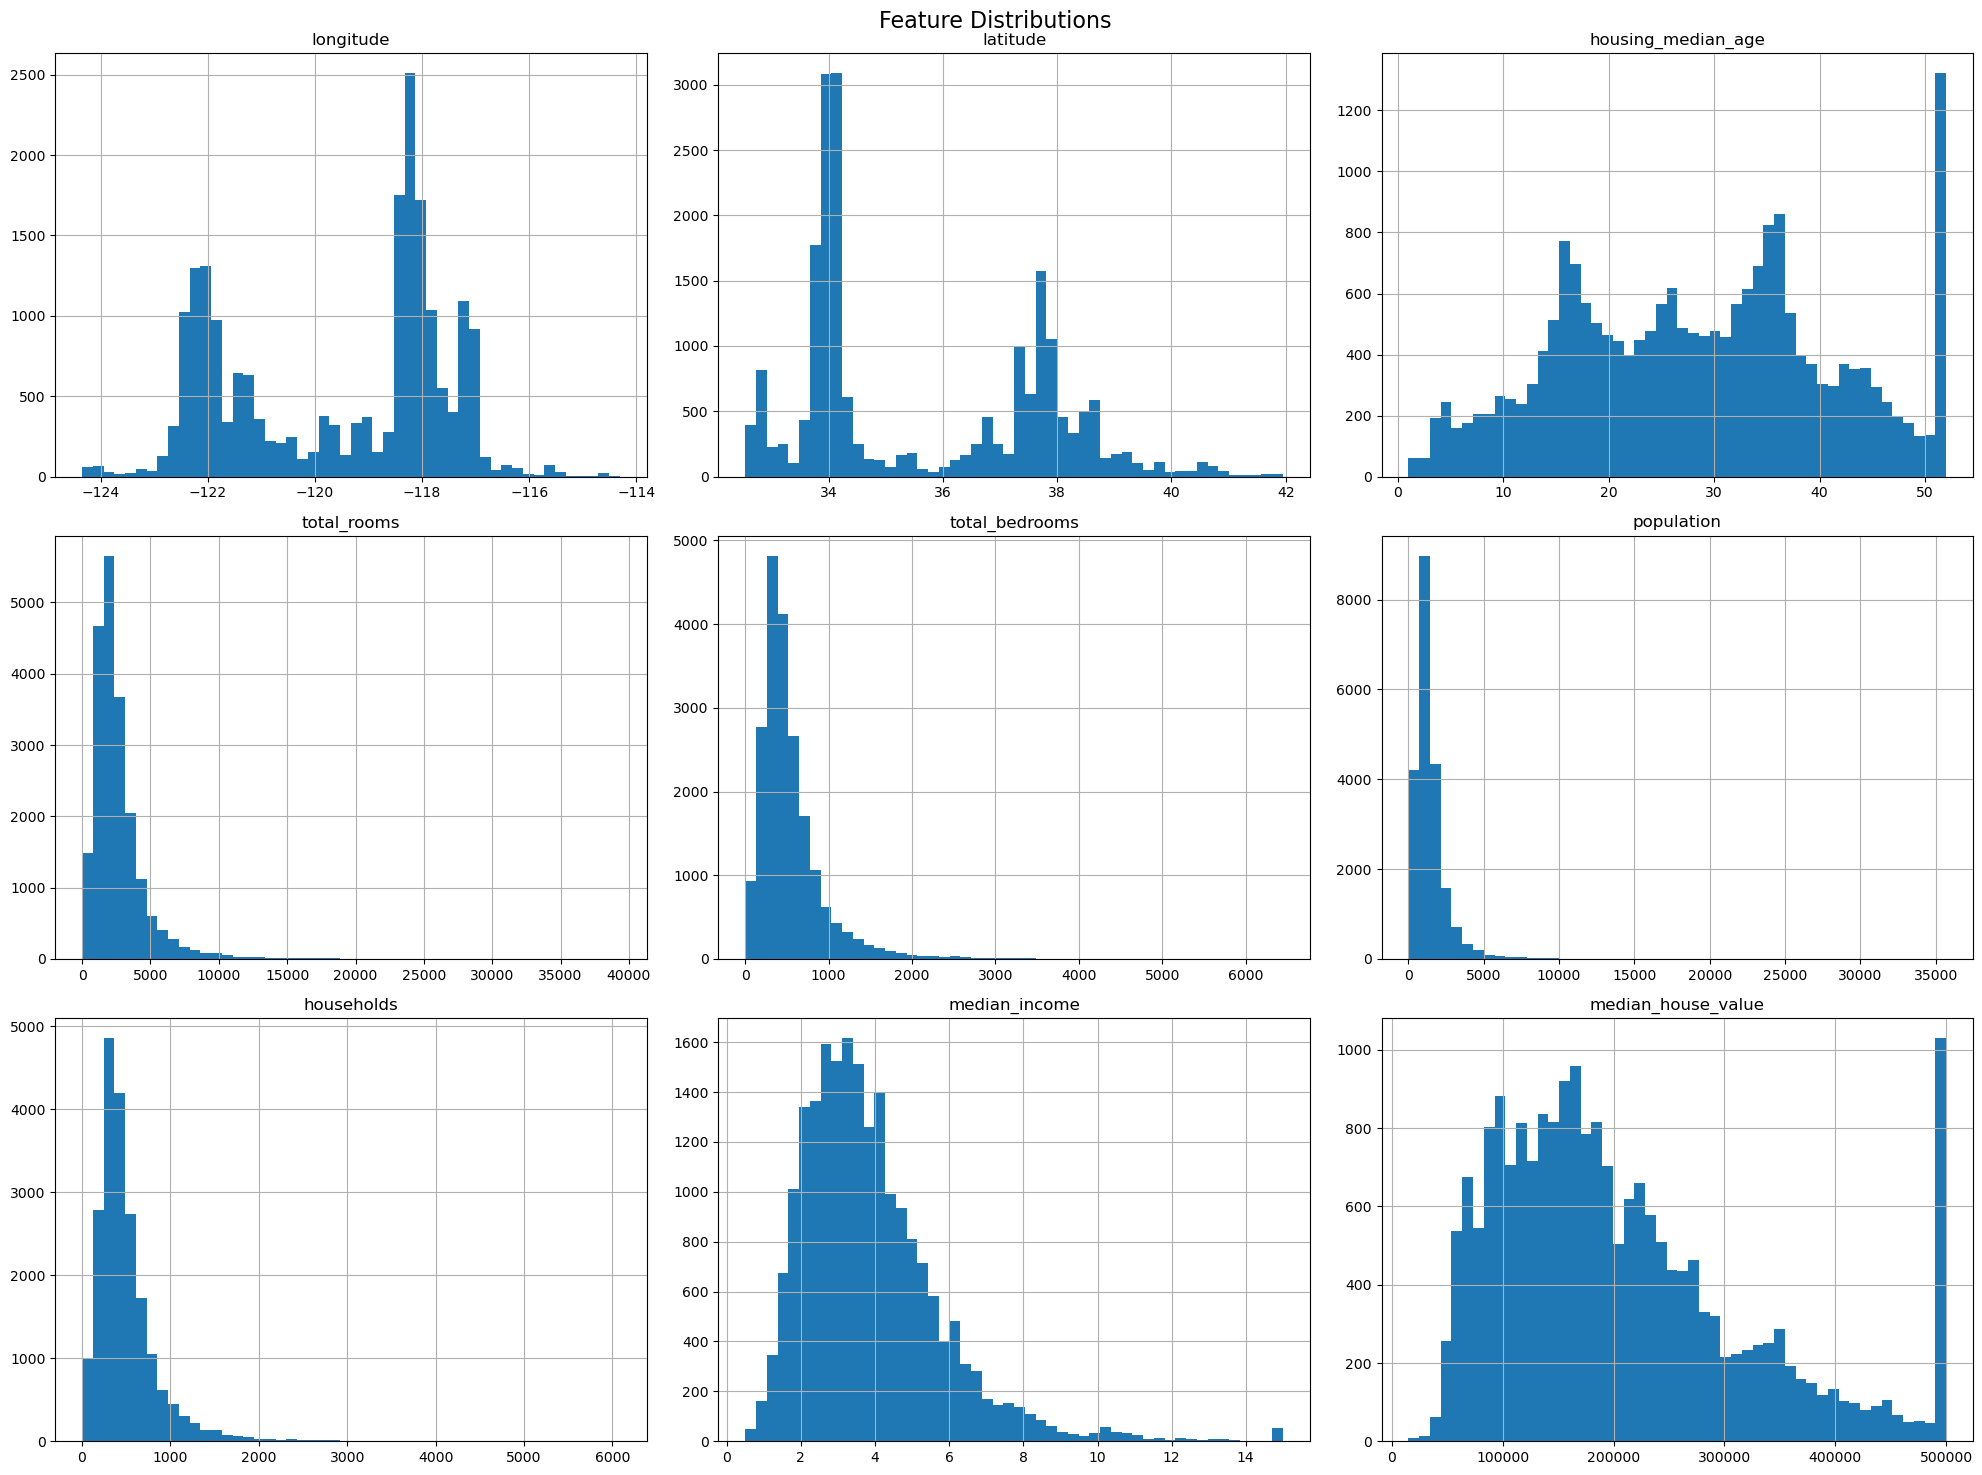

In [6]:
# Histograms of all numeric features
df.hist(bins=50, figsize=(20, 15))
plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

## 2. Stratified Train/Test Split

Using `median_income` categories to ensure a representative split.

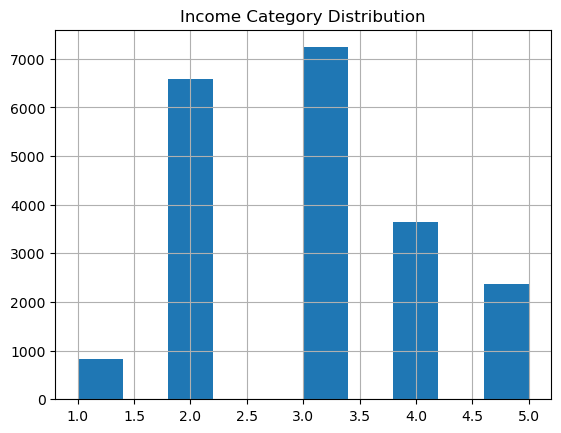

In [7]:
df["income_cat"] = pd.cut(df["median_income"],
                          bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                          labels=[1, 2, 3, 4, 5])
df["income_cat"].hist()
plt.title("Income Category Distribution")
plt.show()

In [8]:
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(df, df["income_cat"]):
    strat_train_set = df.loc[train_index]
    strat_test_set  = df.loc[test_index]

for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

print(f"Train size: {len(strat_train_set)} | Test size: {len(strat_test_set)}")

Train size: 16512 | Test size: 4128


## 3. Exploratory Data Analysis (EDA)

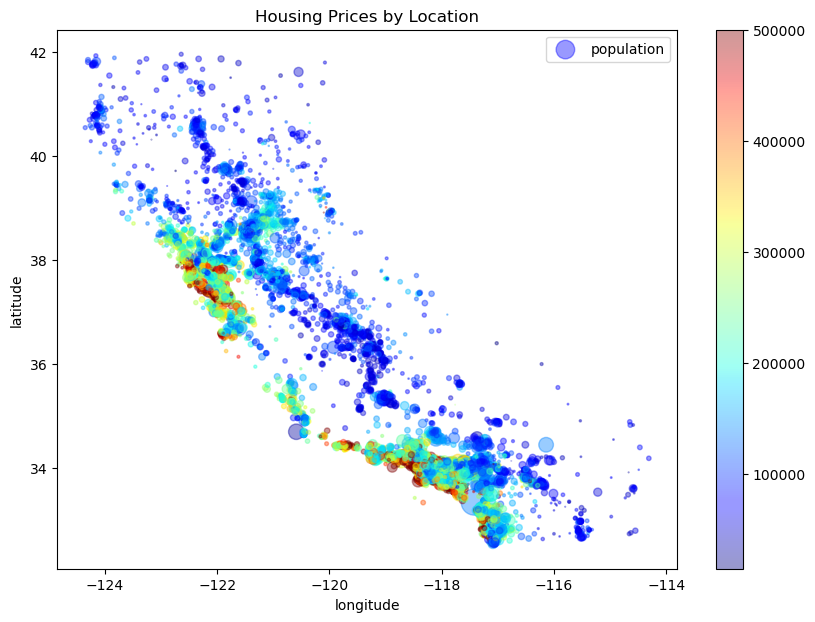

In [9]:
housing = strat_train_set.copy()

housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4,
             s=housing["population"] / 100, label="population", figsize=(10, 7),
             c=housing["median_house_value"], cmap=plt.get_cmap("jet"), colorbar=True)
plt.legend()
plt.title("Housing Prices by Location")
plt.show()

In [10]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.687151
total_rooms           0.135140
housing_median_age    0.114146
households            0.064590
total_bedrooms        0.047781
population           -0.026882
longitude            -0.047466
latitude             -0.142673
Name: median_house_value, dtype: float64

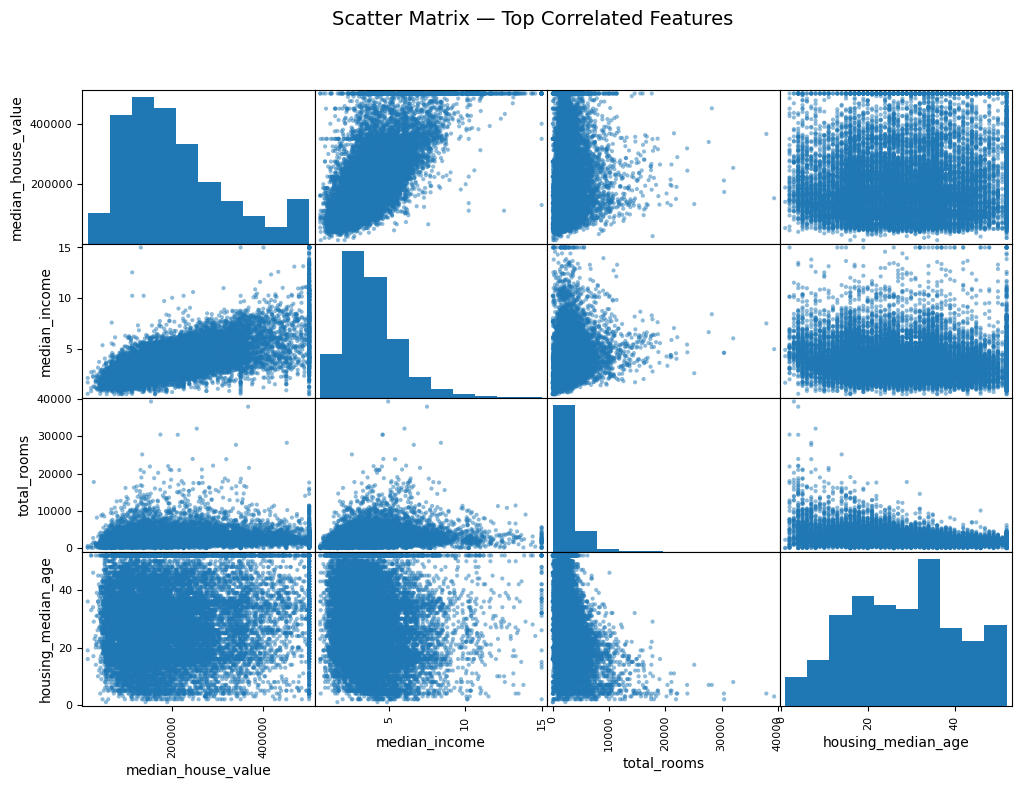

In [11]:
from pandas.plotting import scatter_matrix
attributes = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]
scatter_matrix(housing[attributes], figsize=(12, 8))
plt.suptitle("Scatter Matrix — Top Correlated Features", fontsize=14)
plt.show()

## 4. Feature Engineering

In [12]:
housing["rooms_per_household"]     = housing["total_rooms"]    / housing["households"]
housing["bedrooms_per_room"]        = housing["total_bedrooms"] / housing["total_rooms"]
housing["population_per_household"] = housing["population"]     / housing["households"]

corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value          1.000000
median_income               0.687151
rooms_per_household         0.146255
total_rooms                 0.135140
housing_median_age          0.114146
households                  0.064590
total_bedrooms              0.047781
population_per_household   -0.021991
population                 -0.026882
longitude                  -0.047466
latitude                   -0.142673
bedrooms_per_room          -0.259952
Name: median_house_value, dtype: float64

## 5. Preprocessing Pipeline

In [13]:
df = strat_train_set.drop("median_house_value", axis=1)
df_labels = strat_train_set["median_house_value"].copy()

num_attribs = list(df.drop("ocean_proximity", axis=1))
cat_attribs = ["ocean_proximity"]

# Numeric: impute missing values, then scale
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

# Full pipeline: numeric + one-hot encoding for categorical
my_new_pipeline = ColumnTransformer([
    ("num", num_pipeline,    num_attribs),
    ("cat", OneHotEncoder(), cat_attribs),
])

df_complete_tr = my_new_pipeline.fit_transform(df)
print(f"Transformed training set shape: {df_complete_tr.shape}")

Transformed training set shape: (16512, 13)


## 6. Model Training & Cross-Validation

Comparing Linear Regression, Decision Tree, and Random Forest using 10-fold CV.

In [14]:
def display_scores(scores, model_name=""):
    print(f"Model: {model_name}")
    print(f"  RMSE scores: {scores.round(0)}")
    print(f"  Mean:        {scores.mean():.0f}")
    print(f"  Std:         {scores.std():.0f}")
    print()

In [15]:
lg_model = LinearRegression()
lg_model.fit(df_complete_tr, df_labels)

lin_scores = cross_val_score(lg_model, df_complete_tr, df_labels,
                             scoring="neg_mean_squared_error", cv=10)
display_scores(np.sqrt(-lin_scores), "Linear Regression")

Model: Linear Regression
  RMSE scores: [72229. 65318. 67706. 69369. 66768. 73004. 70522. 69441. 66930. 70756.]
  Mean:        69204
  Std:         2372



In [16]:
df_tree_model = DecisionTreeRegressor()
df_tree_model.fit(df_complete_tr, df_labels)

tree_scores = cross_val_score(df_tree_model, df_complete_tr, df_labels,
                              scoring="neg_mean_squared_error", cv=10)
display_scores(np.sqrt(-tree_scores), "Decision Tree")

Model: Decision Tree
  RMSE scores: [71974. 70241. 66689. 68341. 66514. 68815. 72975. 69639. 65905. 69735.]
  Mean:        69083
  Std:         2205



In [17]:
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(df_complete_tr, df_labels)

for_scores = cross_val_score(rf_model, df_complete_tr, df_labels,
                             scoring="neg_mean_squared_error", cv=10)
display_scores(np.sqrt(-for_scores), "Random Forest")

Model: Random Forest
  RMSE scores: [51039. 48742. 45940. 50501. 47388. 49595. 51626. 48866. 47323. 53301.]
  Mean:        49432
  Std:         2125



## 7. Hyperparameter Tuning — GridSearchCV

In [18]:
param_grid = [
    {"n_estimators": [3, 10, 30], "max_features": [2, 4, 6, 8]},
    {"bootstrap": [False], "n_estimators": [3, 10], "max_features": [2, 3, 4]},
]

forest_reg = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(forest_reg, param_grid, cv=5,
                           scoring="neg_mean_squared_error")
grid_search.fit(df_complete_tr, df_labels)

print("Best parameters:", grid_search.best_params_)

Best parameters: {'max_features': 8, 'n_estimators': 30}


In [19]:
cvres = grid_search.cv_results_
print(f"{'RMSE':<12} Params")
print("-" * 60)
for mean_score, params in zip(cvres["mean_test_score"], cvres["params"]):
    print(f"{np.sqrt(-mean_score):<12.0f} {params}")

RMSE         Params
------------------------------------------------------------
63828        {'max_features': 2, 'n_estimators': 3}
55057        {'max_features': 2, 'n_estimators': 10}
52674        {'max_features': 2, 'n_estimators': 30}
60299        {'max_features': 4, 'n_estimators': 3}
53106        {'max_features': 4, 'n_estimators': 10}
50371        {'max_features': 4, 'n_estimators': 30}
58363        {'max_features': 6, 'n_estimators': 3}
52446        {'max_features': 6, 'n_estimators': 10}
50178        {'max_features': 6, 'n_estimators': 30}
58058        {'max_features': 8, 'n_estimators': 3}
51849        {'max_features': 8, 'n_estimators': 10}
49941        {'max_features': 8, 'n_estimators': 30}
62820        {'bootstrap': False, 'max_features': 2, 'n_estimators': 3}
53846        {'bootstrap': False, 'max_features': 2, 'n_estimators': 10}
59026        {'bootstrap': False, 'max_features': 3, 'n_estimators': 3}
52997        {'bootstrap': False, 'max_features': 3, 'n_estimators': 1

## 8. Final Evaluation on Test Set

In [20]:
final_model = grid_search.best_estimator_

X_test          = strat_test_set.drop("median_house_value", axis=1)
y_test          = strat_test_set["median_house_value"].copy()
X_test_prepared = my_new_pipeline.transform(X_test)

final_predictions = final_model.predict(X_test_prepared)
final_mse         = mean_squared_error(y_test, final_predictions)
final_rmse        = np.sqrt(final_mse)

# 95% Confidence Interval
squared_errors = (final_predictions - y_test) ** 2
interval = np.sqrt(stats.t.interval(
    confidence=0.95,
    df=len(squared_errors) - 1,
    loc=squared_errors.mean(),
    scale=stats.sem(squared_errors),
))

print("=" * 42)
print(f"  Final RMSE:              {final_rmse:,.0f}")
print(f"  95% Confidence Interval: {interval[0]:,.0f} – {interval[1]:,.0f}")
print("=" * 42)

  Final RMSE:              47,860
  95% Confidence Interval: 45,909 – 49,734
